# Krishna Menon
# B.Tech AI I045

## Siamese Network in TensorFlow from Scratch for YouTube

In [ ]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 1.8/332.0 MB 8.5 MB/s eta 0:00:39
   ---------------------------------------- 2.6/332.0 MB 6.6 MB/s eta 0:00:50
   ---------------------------------------- 3.7/332.0 MB 6.1 MB/s eta 0:00:54
    --------------------------------------- 5.2/332.0 MB 6.1 MB/s eta 0:00:54
    --------------------------------------- 6.6/332.0 MB 6.1 MB/s eta 0:00:54
    --------------------------------------- 7.3/332.0 MB 5.8 MB/s eta 0:00:57
    --------------------------------------- 8.1/332.0 MB 5.6 MB/s eta 0:00:59
   - -------------------------------------- 8.9/332.0 MB 5.3 MB/s eta 0:01:01
   - -------------------------------------- 10.0/332.0 MB 5.2 MB/s eta 0:01:02
   - -------------------------------------- 10.7/332.0 MB 5.1 MB/s eta 0:01:04
   - -------------------------------------- 11.5/332.0 MB 5.0 MB/s et

: 

In [ ]:
import tensorflow as tf

mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [3]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential, Model


img_A_inp = Input((28, 28), name='img_A_inp')
img_B_inp = Input((28, 28), name='img_B_inp')

def get_cnn_block(depth):
  return Sequential([Conv2D(depth, 3, 1),
                     BatchNormalization(),
                     ReLU()])

DEPTH = 64
cnn = Sequential([Reshape((28, 28, 1)),
                  get_cnn_block(DEPTH),
                  get_cnn_block(DEPTH*2),
                  get_cnn_block(DEPTH*4),
                  get_cnn_block(DEPTH*8),
                  GlobalAveragePooling2D(),
                  Dense(64, activation='relu')])

feature_vector_A = cnn(img_A_inp)
feature_vector_B = cnn(img_B_inp)

concat = Concatenate()([feature_vector_A, feature_vector_B])

dense = Dense(64, activation='relu')(concat)
output = Dense(1, activation='sigmoid')(dense)

model = Model(inputs=[img_A_inp, img_B_inp], outputs=output)

model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_A_inp           │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_B_inp           │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 64)        │  1,586,496 │ img_A_inp[0][0],  │
│ (Sequential)        │                   │            │ img_B_inp[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ sequential_9[0][… │
│ (Concatenate)       │                   │            │ sequential_9[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,594,817 (6.08 MB)

 Trainable params: 1,592,897 (6.08 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [4]:
import numpy as np

random_indices = np.random.choice(X_train.shape[0], 100, replace=False)

X_train_sample, y_train_sample = X_train[random_indices], y_train[random_indices]

X_train_sample.shape, y_train_sample.shape

((100, 28, 28), (100,))

In [5]:
len(X_train_sample) ** 2

10000

In [6]:
import itertools

def make_paired_dataset(X, y):
  X_pairs, y_pairs = [], []

  tuples = [(x1, y1) for x1, y1 in zip(X, y)]

  for t in itertools.product(tuples, tuples):
    pair_A, pair_B = t
    img_A, label_A = t[0]
    img_B, label_B = t[1]

    new_label = int(label_A == label_B)

    X_pairs.append([img_A, img_B])
    y_pairs.append(new_label)

  X_pairs = np.array(X_pairs)
  y_pairs = np.array(y_pairs)

  return X_pairs, y_pairs

In [7]:
make_paired_dataset(X_train_sample, y_train_sample)

(array([[[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]]],
 
 
        [[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]]],
 
 
        [[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0

In [8]:
X_train_pairs, y_train_pairs = make_paired_dataset(X_train_sample, y_train_sample)

X_train_pairs.shape, y_train_pairs.shape

((10000, 2, 28, 28), (10000,))

In [9]:
random_indices = np.random.choice(X_test.shape[0], 50, replace=False)

X_test_sample, y_test_sample = X_test[random_indices], y_test[random_indices]

X_test_sample.shape, y_test_sample.shape

((50, 28, 28), (50,))

In [10]:
X_test_pairs, y_test_pairs = make_paired_dataset(X_test_sample, y_test_sample)

X_test_pairs.shape, y_test_pairs.shape

((2500, 2, 28, 28), (2500,))

In [11]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(patience=3)

In [13]:
model.fit(x=[X_train_pairs[:, 0, :, :], X_train_pairs[:, 1, :, :]],
          y=y_train_pairs,
          validation_data=([X_test_pairs[:, 0, :, :],
                            X_test_pairs[:, 1, :, :]],
                           y_test_pairs),
          epochs=4,
          batch_size=32,
          callbacks=[es])

Epoch 1/4
 14/313 ━━━━━━━━━━━━━━━━━━━━ 8:17 2s/step - accuracy: 0.7258 - loss: 0.4850

KeyboardInterrupt: 

In [ ]:

img_A, img_B = X_test[0], X_test[17]
label_A, label_B = y_test[0], y_test[17]

label_A, label_B

(np.uint8(7), np.uint8(7))

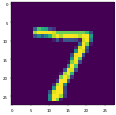

In [ ]:
import matplotlib.pyplot as plt

plt.figure(dpi=28)
plt.imshow(img_A)

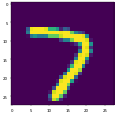

In [ ]:
plt.figure(dpi=28)
plt.imshow(img_B)

In [ ]:
model.predict([img_A.reshape((1, 28, 28)),
               img_B.reshape((1, 28, 28))]).flatten()[0] > 0.5

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step


np.True_

In [30]:
model.save('mnist_siamese_model.keras')

## Changes

In [ ]:
import tensorflow as tf

mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [15]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential, Model


img_A_inp = Input((28, 28), name='img_A_inp')
img_B_inp = Input((28, 28), name='img_B_inp')

def get_cnn_block(depth):
  return Sequential([Conv2D(depth, 3, 1),
                     BatchNormalization(),
                     ReLU()])

DEPTH = 64
cnn = Sequential([Reshape((28, 28, 1)),
                  get_cnn_block(DEPTH),
                  get_cnn_block(DEPTH*2),
                  get_cnn_block(DEPTH*4),
                  get_cnn_block(DEPTH*8),
                  GlobalAveragePooling2D(),
                  Dense(64, activation='relu')])

feature_vector_A = cnn(img_A_inp)
feature_vector_B = cnn(img_B_inp)

# Calculate Euclidean distance
squared_difference = tf.keras.ops.square(feature_vector_A - feature_vector_B)
sum_squared_difference = tf.keras.ops.sum(squared_difference, axis=-1, keepdims=True)
# Add a small epsilon for numerical stability, especially for sqrt(0)
output = tf.keras.ops.sqrt(tf.keras.ops.maximum(sum_squared_difference, tf.keras.backend.epsilon()))

model = Model(inputs=[img_A_inp, img_B_inp], outputs=output)

model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_A_inp           │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_B_inp           │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_14       │ (None, 64)        │  1,586,496 │ img_A_inp[0][0],  │
│ (Sequential)        │                   │            │ img_B_inp[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 64)        │          0 │ sequential_14[0]… │
│                     │                   │            │ sequential_14[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ square (Square)     │ (None, 64)        │          0 │ subtract[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum (Sum)           │ (None, 1)         │          0 │ square[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maximum (Maximum)   │ (None, 1)         │          0 │ sum[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sqrt (Sqrt)         │ (None, 1)         │          0 │ maximum[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,586,496 (6.05 MB)

 Trainable params: 1,584,576 (6.04 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [16]:
import numpy as np

random_indices = np.random.choice(X_train.shape[0], 100, replace=False)

X_train_sample, y_train_sample = X_train[random_indices], y_train[random_indices]

X_train_sample.shape, y_train_sample.shape

((100, 28, 28), (100,))

In [17]:
len(X_train_sample) ** 2

10000

In [18]:
import itertools

def make_paired_dataset(X, y):
  X_pairs, y_pairs = [], []

  tuples = [(x1, y1) for x1, y1 in zip(X, y)]

  for t in itertools.product(tuples, tuples):
    pair_A, pair_B = t
    img_A, label_A = t[0]
    img_B, label_B = t[1]

    new_label = int(label_A == label_B)

    X_pairs.append([img_A, img_B])
    y_pairs.append(new_label)

  X_pairs = np.array(X_pairs)
  y_pairs = np.array(y_pairs)

  return X_pairs, y_pairs

In [19]:
make_paired_dataset(X_train_sample, y_train_sample)

(array([[[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]]],
 
 
        [[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]]],
 
 
        [[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0

In [20]:
X_train_pairs, y_train_pairs = make_paired_dataset(X_train_sample, y_train_sample)

X_train_pairs.shape, y_train_pairs.shape

((10000, 2, 28, 28), (10000,))

In [21]:
random_indices = np.random.choice(X_test.shape[0], 100, replace=False)

X_test_sample, y_test_sample = X_test[random_indices], y_test[random_indices]

X_test_sample.shape, y_test_sample.shape

((100, 28, 28), (100,))

In [22]:
X_test_pairs, y_test_pairs = make_paired_dataset(X_test_sample, y_test_sample)

X_test_pairs.shape, y_test_pairs.shape

((10000, 2, 28, 28), (10000,))

In [23]:
def contrastive_loss(y_true, y_pred, margin=1):
  square_pred = tf.square(y_pred)
  margin_square = tf.square(tf.maximum(margin - y_pred, 0))
  return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)

In [41]:
def contrastive_loss(y_true, y_pred, margin=1.0):
    """
    Computes Contrastive Loss in TensorFlow.

    Args:
        y_true: Ground truth labels (1 for similar, 0 for dissimilar).
        y_pred: The distance between the pair of embeddings.
                (Note: Usually calculated as tf.norm(emb1 - emb2, axis=-1))
        margin: Minimum distance for negative pairs.
    """
    # Ensure labels are float32
    y_true = tf.cast(y_true, tf.float32)

    # Positive pairs: minimize the squared distance
    pos_loss = y_true * tf.square(y_pred)

    # Negative pairs: maximize distance until it reaches the margin
    neg_loss = (1 - y_true) * tf.square(tf.maximum(margin - y_pred, 0.0))

    return tf.reduce_mean(pos_loss + neg_loss)

In [24]:
def dist_accuracy(y_true, y_pred):
    # Ensure labels are float32 for comparison
    y_true = tf.cast(y_true, tf.float32)
    # If distance < 0.5, we predict 1 (Same), else 0 (Different)
    # Note: We use < because y_true=1 means same, and distance should be low.
    pred = tf.cast(y_pred < 0.5, tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, pred), tf.float32))

In [25]:
model.compile(loss=contrastive_loss,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=[dist_accuracy])

In [44]:
from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(patience=3)

In [ ]:
model.fit(x=[X_train_pairs[:, 0, :, :], X_train_pairs[:, 1, :, :]],
          y=y_train_pairs,
          validation_data=([X_test_pairs[:, 0, :, :],
                            X_test_pairs[:, 1, :, :]],
                           y_test_pairs),
          epochs=4,
          batch_size=32,
          callbacks=[es])

Epoch 1/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - dist_accuracy: 0.8088 - loss: 0.0064 - val_dist_accuracy: 0.8220 - val_loss: 0.0573
Epoch 2/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - dist_accuracy: 0.7979 - loss: 0.0033 - val_dist_accuracy: 0.8253 - val_loss: 0.0591
Epoch 3/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - dist_accuracy: 0.7920 - loss: 0.0036 - val_dist_accuracy: 0.8213 - val_loss: 0.0637
Epoch 4/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - dist_accuracy: 0.7993 - loss: 0.0022 - val_dist_accuracy: 0.8208 - val_loss: 0.0612


In [ ]:
img_A, img_B = X_test[0], X_test[17]
label_A, label_B = y_test[0], y_test[17]

label_A, label_B

(np.uint8(7), np.uint8(7))

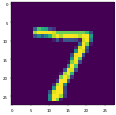

In [ ]:
import matplotlib.pyplot as plt

plt.figure(dpi=28)
plt.imshow(img_A)

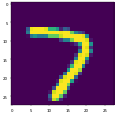

In [ ]:
plt.figure(dpi=28)
plt.imshow(img_B)

In [ ]:
model.predict([img_A.reshape((1, 28, 28)),
               img_B.reshape((1, 28, 28))]).flatten()[0] < 0.5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


np.True_

In [ ]:
model.save('mnist_cooked_siamese_model.keras')

## Loading the model

In [ ]:
take 4 images for few shot and test a query image

In [26]:
import tensorflow as tf
loaded_model = tf.keras.models.load_model(
    'mnist_cooked_siamese_model.keras',
    custom_objects={'contrastive_loss': contrastive_loss, 'dist_accuracy': dist_accuracy}
)

print("Model loaded successfully.")
loaded_model.summary()

Model loaded successfully.


Model: "functional_52"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_A_inp           │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_B_inp           │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_44       │ (None, 64)        │  1,586,496 │ img_A_inp[0][0],  │
│ (Sequential)        │                   │            │ img_B_inp[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_4          │ (None, 64)        │          0 │ sequential_44[0]… │
│ (Subtract)          │                   │            │ sequential_44[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ square (Square)     │ (None, 64)        │          0 │ subtract_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_1 (Sum)         │ (None, 1)         │          0 │ square[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maximum (Maximum)   │ (None, 1)         │          0 │ sum_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sqrt (Sqrt)         │ (None, 1)         │          0 │ maximum[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,755,650 (18.14 MB)

 Trainable params: 1,584,576 (6.04 MB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 3,169,154 (12.09 MB)

In [37]:
num_support_images = 4

# Get the number of available samples in X_test
num_test_samples = X_test.shape[0]

# Select 4 unique random indices from the test dataset
support_indices = np.random.choice(num_test_samples, num_support_images, replace=False)

# Create X_support and y_support using the selected indices
X_support = X_test[support_indices]
y_support = y_test[support_indices]

print(f"Selected {num_support_images} support images with shapes: X_support {X_support.shape}, y_support {y_support.shape}")
print(f"Support indices: {support_indices}")


Selected 4 support images with shapes: X_support (4, 28, 28), y_support (4,)
Support indices: [3843 1948 6818 7592]


In [38]:
all_indices = np.arange(num_test_samples)
remaining_indices = np.setdiff1d(all_indices, support_indices)

# Select one random index for the query image from the remaining indices
query_index = np.random.choice(remaining_indices, 1, replace=False)[0]

# Create X_query and y_query
X_query = X_test[query_index]
y_query = y_test[query_index]

print(f"Selected query image with shape: X_query {X_query.shape}, y_query {y_query.shape}")
print(f"Query index: {query_index}")
print(f"Query label: {y_query}")

Selected query image with shape: X_query (28, 28), y_query ()
Query index: 4401
Query label: 2


In [31]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 6.3 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 5.7 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 4.7 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 4.6 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 4.1 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 4.1 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 4.4 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 4.3 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------- --------------------

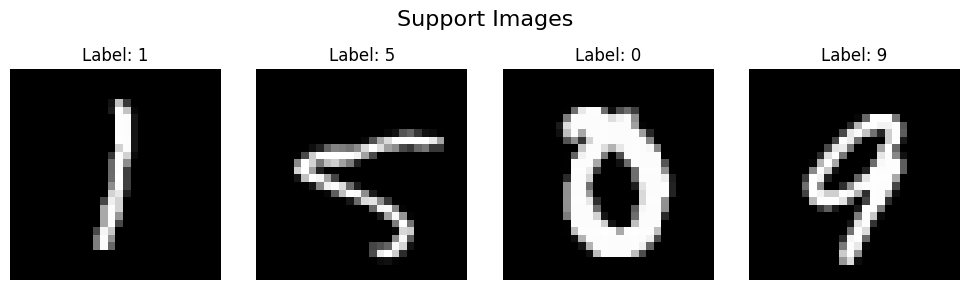

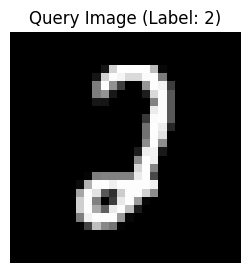

In [39]:
import matplotlib.pyplot as plt

# Display support images
plt.figure(figsize=(10, 3))
plt.suptitle("Support Images", fontsize=16)
for i in range(num_support_images):
    plt.subplot(1, num_support_images, i + 1)
    plt.imshow(X_support[i], cmap='gray')
    plt.title(f"Label: {y_support[i]}")
    plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Display query image
plt.figure(figsize=(3, 3))
plt.imshow(X_query, cmap='gray')
plt.title(f"Query Image (Label: {y_query})")
plt.axis('off')
plt.show()

In [40]:
X_query_reshaped = X_query[np.newaxis, :, :]

similarity_scores = []
for i in range(num_support_images):
    support_image = X_support[i]
    support_image_reshaped = support_image[np.newaxis, :, :]

    # Predict the similarity distance
    distance = loaded_model.predict([X_query_reshaped, support_image_reshaped]).flatten()[0]
    similarity_scores.append(distance)

    print(f"Similarity (Distance) between Query (Label {y_query}) and Support Image {i} (Label {y_support[i]}): {distance:.4f}")

# Find the support image with the minimum distance (most similar)
min_distance_index = np.argmin(similarity_scores)
min_distance = similarity_scores[min_distance_index]

print(f"\nMinimum distance found: {min_distance:.4f} with Support Image {min_distance_index} (Label {y_support[min_distance_index]})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Similarity (Distance) between Query (Label 2) and Support Image 0 (Label 1): 1.0022
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Similarity (Distance) between Query (Label 2) and Support Image 1 (Label 5): 1.0185
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Similarity (Distance) between Query (Label 2) and Support Image 2 (Label 0): 0.4070
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Similarity (Distance) between Query (Label 2) and Support Image 3 (Label 9): 1.1132

Minimum distance found: 0.4070 with Support Image 2 (Label 0)


In [41]:
similarity_scores

[np.float32(1.0022033),
 np.float32(1.0184591),
 np.float32(0.40704075),
 np.float32(1.1132435)]

In [42]:
predicted_class = y_support[min_distance_index]
true_class = y_query

is_correct_prediction = (predicted_class == true_class)

print(f"\nTrue Label of Query Image: {true_class}")
print(f"Predicted Label (from most similar support image): {predicted_class}")
print(f"Prediction Correct: {is_correct_prediction}")


True Label of Query Image: 2
Predicted Label (from most similar support image): 0
Prediction Correct: False
